<a href="https://colab.research.google.com/github/CervantesMCinthiaK/Investigacion-de-Operaciones-/blob/main/Tutorial1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color="purple"> ***"TUTORIAL NETWORKX 1 DE PYTHON"***


Alumna: Cervantes Martinez Cinthia Karina

---


En este cuaderno se describe la solución de 3 problemas de redes:

**1) del árbol de expansión mínima.**

**2) de la ruta más corta.**

**3) del flujo máximo.**

Este cuardeno esta basado en la documentación de: ((Networkx 1)(https://networkx.org/en/)


<font color="blue">**NetworkX** </font> es un paquete de Python para la creación, manipulación y estudio de la estructura, dinámica y funciones de redes complejas.

Se utiliza para estudiar diferentes tipos de redes, como sociales, biológicas y de infraestructura. Además, permite generar redes, encontrar rutas, analizar su estructura y aplicar algoritmos.   

Puede integrarse con otras herramientas y lenguajes para mejorar el rendimiento de los algoritmos como en C, C++ y FORTRAN.



---



#<font color="pink"> ***ÁRBOL DE EXPANSIÓN MÍNIMA***

El problema del árbol de expansión mínima se puede resumir de la siguiente manera:
* Se tienen los nodos de una red pero no las ligaduras. En su lugar se proporcionan las ligaduras potenciales y la longitud positiva de cada una si se insertan en la red. (Las medidas alternativas para la longitud de una ligadura incluyen distancia, costo y tiempo.)
*   Se desea diseñar la red con suficientes ligaduras para satisfacer el requisito de que haya un camino entre cada par de nodos.
*   El objetivo es satisfacer este requisito de manera que se minimice la longitud total de las ligaduras insertadas en la red.

<font face="Times New Roman" color="pink" size="5"><b>Algoritmo</b></font>

Los pasos del procedimiento son los siguientes. Sea $N = \{1, 2, \dots, n\}$ el conjunto de nodos de la red, y se definen:


<font color="pink"> **$C_k$** </font> =Conjunto de nodos que se han conectado en forma permanente en la iteración.


<font color="pink">**$\bar{C}_k$** </font>= Conjunto de nodos que todavía se deben conectar en forma permanente.


<font color="pink">**Paso 0.** </font> El conjunto $C_0 = \varnothing$ y $\bar{C}_0 = N$.

<font color="pink">**Paso 1.** </font> Comenzar con *cualquier* nodo en el conjunto $\bar{C}_0$ no conectado (o "inconexo"), e igualar $C_1 = \{i\}$, con lo que $\bar{C}_1 = N - \{i\}$. Igualar $k = 2$.

<font color="pink">**Paso general $k$:**</font> Seleccionar un nodo $j^*$ en el conjunto no conectado $\bar{C}_{k-1}$ que produzca el arco más corto a un nodo en el conjunto conectado $C_{k-1}$. Enlazar a $j^*$ en forma permanente con $C_{k-1}$ y sacarlo de $\bar{C}_{k-1}$, esto es:

$$
C_k = C_{k-1} \cup \{j^*\}
$$

$$
\bar{C}_k = \bar{C}_{k-1} \setminus \{j^*\}
$$

Si el conjunto $\bar{C}_k$ de nodos no conectados es vacío, detenerse. En cualquier otro caso, igualar $k = k + 1$ y repetir el paso.



Para el ejemplo, debemos considerar la red no dirigida, en este caso haremos la imagen 1 en red no dirigida.


*  Primero debes de poner las librerias que se usaran en este caso son :



In [137]:
import networkx as nx   #es la biblioteca que utilizaremos para trabajar con grafos y redes
import matplotlib.pyplot as plt  #para graficar

*   Creamos un grafo vacío, es decir, sin nodos ni aristas.



In [138]:
G = nx.Graph() #grafo no dirigido



*   Agregamos los nodos de la red y sus atributos en este caso con el color     deseado con el formato :(node, node_attribute_dict)



In [139]:
G.add_nodes_from([
    (1, {"color": "red"}),
    (2, {"color": "red"}),
    (3, {"color": "red"}),
    (4, {"color": "red"}),
    (5, {"color": "red"}),
    (6, {"color": "red"}),
    (7, {"color": "red"})
])



*   G también puede crecer añadiéndole aristas, se puede añadir un borde  con add_edge() o una lista de bordes con add_edges_from(). Con sus respectivos atributos: su color y su valor que en este caso se utiliza el comando "weight" de Networkx que significa peso o valor asociado a una arista (la línea que conecta dos nodos).




In [140]:
G.add_edges_from([(1,2, {"color": "green","weight": 5}),
                  (1,3, {"color": "green","weight": 1}),
                  (2,5, {"color": "green","weight": 1}),
                  (2,6, {"color": "green","weight": 6}), # Se toma el valor mínimo entre 6 y 7
                  (2,4, {"color": "green","weight": 7}),
                  (3,2, {"color": "green","weight": 2}),
                  (3,4, {"color": "green","weight": 6}), # Se toma el valor mínimo entre 6 y 7
                  (3,5, {"color": "green","weight": 7}),
                  (4,6, {"color": "green","weight": 4}),
                  (4,7, {"color": "green","weight": 6}),
                  (5,4, {"color": "green","weight": 3}),
                  (5,6, {"color": "green","weight": 5}),
                  (5,7, {"color": "green","weight": 9}),
                  (6,7, {"color": "green","weight": 2})
                  ])



*   Obtenemos el color que tiene asignado cada nodo del grafo y lo guardamos en una lista para después poder usarlos al dibujar el grafo



In [141]:
node_colors = [
    G.nodes[n]["color"] #obtiene el color
    for n in G.nodes() #para cada nodo del grafo
]



*   Obtenemos el color de cada arista de igual manera para después poder usarlos al dibujar el grafo



In [142]:
edge_colors = [
    G[u][v]["color"]
    for u, v in G.edges()
]



*   Definimos la la posición de cada nodo con el formato : pos = {número_del_nodo: (posición_x, posición_y)}



In [143]:
pos = {
    1: (-1, 0.3),
    2: (1, 0.7),
    3: (1, 0),
    4: (5, 0.3),
    5: (9, 0),
    6: (9, 0.7),
    7: (11, 0.3)
}




*   Definimos las características para dibujar el grafo



In [144]:
options = {
    "font_size": 36, #Cambia el tamaño de los números o nombres de los nodos
    "node_size": 3000, #Cambia el tamaño de los números o nombres de los nodos(circulos)
    "edgecolors": "black", #Cambia el color del borde de los nodos
    "linewidths": 5, #Cambia el grosor del borde de los nodos
    "width": 5,  #Cambia el grosor de las aristas (lineas)
}




*   Dibujamos el grafo, utilizando ***nx.draw()*** que es un comando de la biblioteca NetworkX que dibuja el grafo G y coloca cada nodo en la posición indicada en pos.



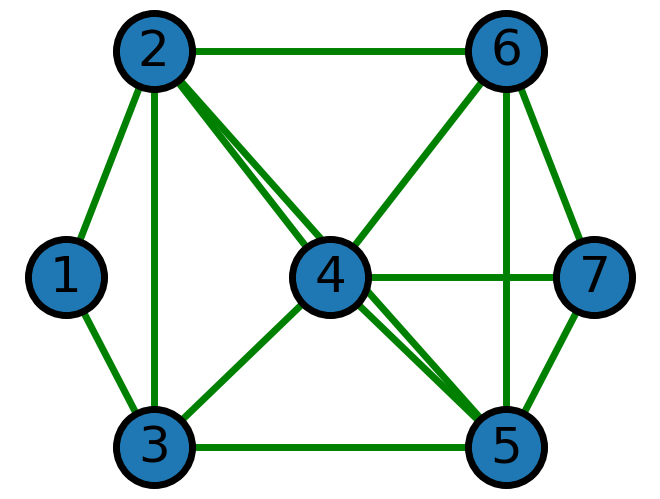

In [145]:
# Dibujamos el grafo.
nx.draw(
    G,
    pos,
    with_labels=True,
    edge_color=edge_colors,
    **options

)


* Obtenemos los valores y los mostramos utilizando:

  **weight:** guarda el valor de cada arista.

  **get_edge_attributes():** obtiene esos valores.

  **draw_networkx_edge_labels():** muestra los valores sobre las aristas en el dibujo.



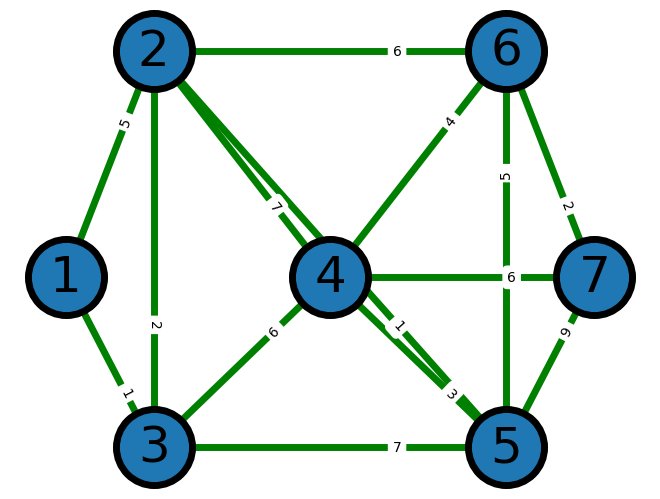

In [146]:
# Dibujamos el grafo nuevamente
nx.draw(
    G,
    pos,
    with_labels=True,
    edge_color=edge_colors,
    **options

)

# Obtenemos los valores
edge_labels = nx.get_edge_attributes(G, "weight")

# Mostramos los valores
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    label_pos=0.7
)


#Mostramos el grafo
plt.show()



*   Como ya graficamos la red, ahora debemos resolverlo para encontrar el árbol de expansión mínima. Usando  minimum_spanning_tree() que es el comando que busca el árbol de expansión mínima.
T guarda el nuevo grafo que contiene únicamente las aristas necesarias para conectar todos los nodos con el menor peso total posible.

In [147]:
T = nx.minimum_spanning_tree(G, weight="weight")





*   Dibujamos el árbol de expansión mínima utilizando nx.draw
    *  nx.get_edge_attributes() es una función de NetworkX que obtiene los atributos de las aristas.
    *  tree_edge_labels guarda esos valores para poder utilizarlos después.
    *  nx.draw_networkx_edge_labels muestra los valores de las aristas sobre el dibujo del árbol


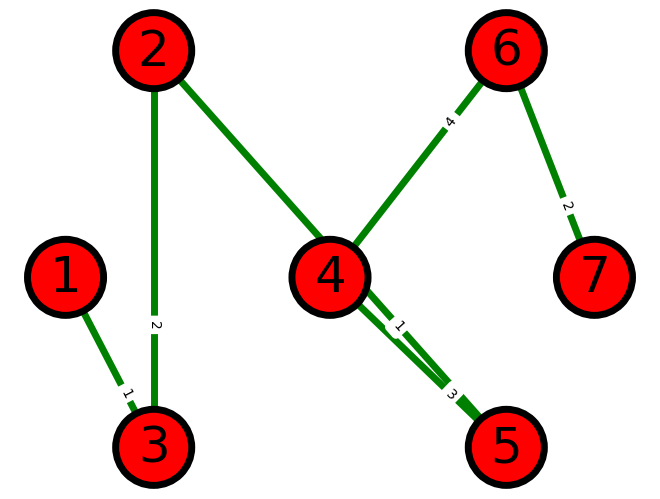

In [148]:
# Dibujamos el arbol
nx.draw(
    T,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color="green",
    **options
)

# Obtenemos las longitudes de las rutas.
tree_edge_labels = nx.get_edge_attributes(T, "weight")

# Mostramos los  valores
nx.draw_networkx_edge_labels(
    T,
    pos,
    edge_labels=tree_edge_labels,
    label_pos=0.7
)

# Quitamos los ejes.
plt.axis("off")

# Mostramos el arbol de expansion minima.
plt.show()

*   Mostramos las rutas seleccionadas y calculamos la longitud total del árbol


In [149]:
ruta = nx.shortest_path(T, source=1, target=7)

print("Ruta del árbol de expansión mínima:")
print(" - ".join(map(str, ruta)))

# Calculamos el peso total del árbol.
peso_total = T.size(weight="weight")

print("Longitud total del árbol:", peso_total)

Ruta del árbol de expansión mínima:
1 - 3 - 2 - 5 - 4 - 6 - 7
Longitud total del árbol: 13.0


Y por lo tanto, concluimos con el ejercicio.

---



#<font color="blue"> ***DE LA RUTA MÁS CORTA***

En este algoritmo el objetivo es encontrar la ruta mas corta, la trayectoria de la minima distancia total del origen al destino.

<font face="Times New Roman" color="blue" size="4"><b>Objetivo de la n-ésima iteración</b></font>

Encontrar el n-ésimo nodo más cercano al origen. Este paso se repite para  
n = 1, 2, ...,  hasta que el n-ésimo nodo más cercano sea el nodo destino.

<font face="Times New Roman" color="blue" size="4"><b>Datos de la n-ésima iteración</b></font>

n - 1 nodos más cercanos al origen —que se encontraron en las iteraciones previas—, incluida su ruta más corta y la distancia desde el origen.

Estos nodos y el origen se llaman **nodos resueltos**; el resto son **nodos no resueltos**.

<font face="Times New Roman" color="blue" size="4"><b>Candidatos para n-ésimo nodo más cercano</b></font>


Cada nodo resuelto que tiene conexión directa por una ligadura con uno o más nodos no resueltos proporciona un candidato, esto es, el nodo no resuelto que tiene la ligadura más corta. Los empates proporcionan candidatos adicionales.

<font face="Times New Roman" color="blue" size="4"><b>Cálculo del n-ésimo nodo más cercano</b></font>


Para cada nodo resuelto y sus candidatos, se suma la distancia entre ellos y la distancia de la ruta más corta desde el origen a este nodo resuelto.

El candidato con la distancia total más pequeña es el n-ésimo nodo más cercano.

Los empates proporcionan nodos resueltos adicionales, y su ruta más corta es la que genera esta distancia.



Para el ejemplo, debemos considerar la red dirigida, en este caso haremos la imagen 1 en red  dirigida.


*  Primero debes de poner las librerias que se usaran en este caso son :

In [150]:
import networkx as nx
import matplotlib.pyplot as plt

*  Creamos un grafo vacío, es decir, sin nodos ni aristas, en este caso usaremos el comando G = nx.DiGraph()

   Un DiGraph almacena nodos y aristas con datos o atributos opcionales.
   Los digrafos contienen aristas dirigidas. Se permiten bucles propios, pero no aristas múltiples (paralelas).


In [151]:
G = nx.DiGraph()

*   Agregamos los nodos de la red y sus atributos en este caso con el color deseado con el formato :(node, node_attribute_dict)



In [152]:
G.add_nodes_from([
    (1, {"color": "green"}),
    (2, {"color": "green"}),
    (3, {"color": "green"}),
    (4, {"color": "green"}),
    (5, {"color": "green"}),
    (6, {"color": "green"}),
    (7, {"color": "green"})
])

*   G también puede crecer añadiéndole aristas, se puede añadir un borde  con add_edge() o una lista de bordes con add_edges_from(). Con sus respectivos atributos: su color y su valor que en este caso se utiliza el comando "weight" de Networkx que significa peso o valor asociado a una arista (la línea que conecta dos nodos).  Como es dirigida ponemos todos los bordes en su direccion correspondientes

In [153]:
G.add_edges_from([(1,2, {"color": "green","weight": 5}),
                  (1,3, {"color": "green","weight": 1}),
                  (2,5, {"color": "green","weight": 1}),
                  (2,6, {"color": "red","weight": 6}),
                  (2,4, {"color": "green","weight": 7}),
                  (3,2, {"color": "green","weight": 2}),
                  (3,4, {"color": "red","weight": 6}),
                  (3,5, {"color": "green","weight": 7}),
                  (4,3, {"color": "green","weight": 7}),
                  (4,6, {"color": "green","weight": 4}),
                  (4,7, {"color": "green","weight": 6}),
                  (5,4, {"color": "green","weight": 3}),
                  (5,6, {"color": "green","weight": 5}),
                  (5,7, {"color": "green","weight": 9}),
                  (6,2, {"color": "green","weight": 7}),
                  (6,7, {"color": "green","weight": 2})
                  ])

*   Obtenemos el color que tiene asignado cada nodo del grafo y lo guardamos en una lista para después poder usarlos al dibujar el grafo

In [154]:
node_colors = [
    G.nodes[n]["color"]
    for n in G.nodes()
]




*   Obtenemos el color de cada arista de igual manera para después poder usarlos al dibujar el grafo

In [155]:
edge_colors = [
    G[u][v]["color"]
    for u, v in G.edges()
]


*   Definimos la la posición de cada nodo con el formato : pos = {número_del_nodo: (posición_x, posición_y)}








In [156]:
# Definimos la posición de cada nodo.
pos = {
    1: (-4, 0),
    2: (1, 1),
    3: (1, -1),
    4: (12, 0),
    5: (18, -1),
    6: (18, 1),
    7: (24, 0)
}




*   Definimos las características para dibujar el grafo.



In [157]:
options = {
    "font_size": 36,
    "node_size": 3000,
    "edgecolors": "black",
    "linewidths": 5,
    "width": 5,
}


*   Dibujamos el grafo, utilizando ***nx.draw()*** que es un comando de la biblioteca NetworkX que dibuja el grafo G y coloca cada nodo en la posición indicada en pos.

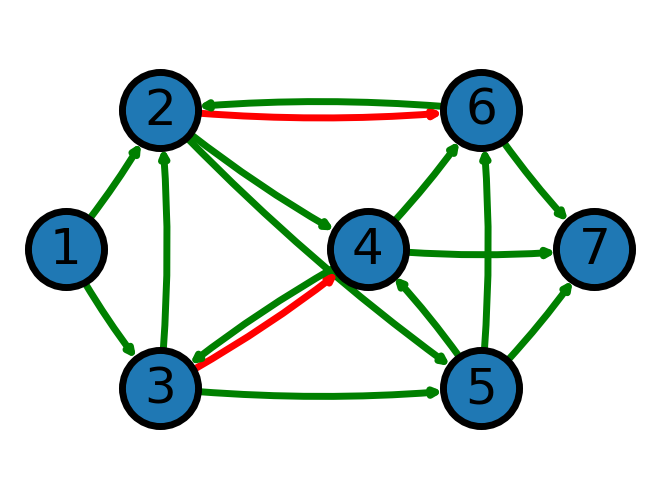

In [158]:
# Dibujamos el grafo.
nx.draw(
    G,
    pos,
    with_labels=True,
    edge_color=edge_colors,
    connectionstyle="arc3,rad=0.05",
    **options
)


* Obtenemos los valores y los mostramos utilizando:

  **weight:** guarda el valor de cada arista.

  **get_edge_attributes():** obtiene esos valores.

  **draw_networkx_edge_labels():** muestra los valores sobre las aristas en el dibujo.


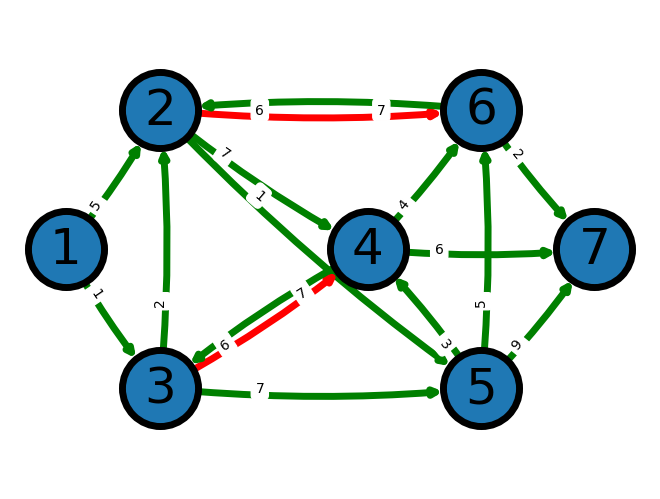

In [159]:
# Dibujamos el grafo.
nx.draw(
    G,
    pos,
    with_labels=True,
    edge_color=edge_colors,
    connectionstyle="arc3,rad=0.05",
    **options
)


# Obtenemos los valores
edge_labels = nx.get_edge_attributes(G, "weight")

# Mostramos los valores
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    label_pos=0.3
)

# Mostramos el grafo.
plt.show()



*   Ahora bien, encontramos la ruta más corta de 1 a 7, utilizando:
    * nx.dijkstra_path(): encuentra la ruta más corta usando el algoritmo de Dijkstra.
    * source=1:Indica que la ruta empieza en el nodo 1.
    * target=7: Indica que la ruta termina en el nodo 7.
    * weight="weight":  utiliza los valores de las aristas para determinar cuál ruta tiene menor costo.
    * nx.shortest_path_length()  calcula la longitud o costo total de la ruta más corta.


In [160]:
ruta = nx.dijkstra_path(G, source=1, target=7, weight="weight")
print("Ruta más corta:", ruta)


distancia = nx.shortest_path_length(
    G,source=1,target=7, weight="weight"
)

print("Longitud:", distancia)


Ruta más corta: [1, 3, 2, 6, 7]
Longitud: 11


* Obtenemos los valores y los mostramos utilizando:
  
  **nx.draw_networkx_edge_labels():** muestra los valores(longitudes) de las aristas sobre el grafo.

  **edge_labels=edge_labels** utiliza los valores(longitudes) que obtuvimos.


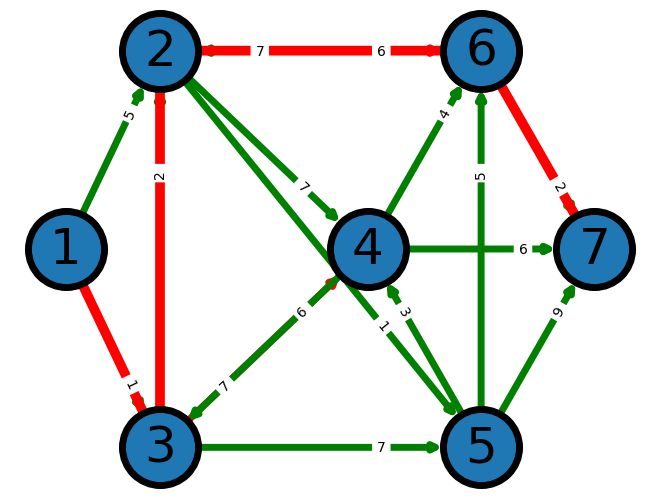

In [161]:
# Aristas que forman la ruta
aristas_ruta = list(zip(ruta[:-1], ruta[1:]))

# Dibujamos el grafo completo
nx.draw(
    G,
    pos,
    with_labels=True,
    edge_color=edge_colors,
    **options
)

# Resaltamos la ruta más corta
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=aristas_ruta,
    edge_color="red",
    width=7,
    arrows=True
)

# Valores de las aristas
edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    label_pos=0.7
)

plt.show()

Finalmente, obtenemos la solución y mostramos el grafo, resaltando la ruta más corta.


---



#<font color="green"> ***FLUJO MÁXIMO***

El algoritmo es:

1. **Se identifica una trayectoria de aumento** cuando se encuentra alguna trayectoria dirigida del origen al destino en la red residual, tal que cada arco sobre ella tenga capacidad residual estrictamente positiva. (Si no existe una, los flujos netos asignados constituyen un patrón de flujo óptimo.)

2. Cuando se encuentra el **mínimo de las capacidades residuales** de los arcos sobre esta trayectoria se identifica la capacidad residual c* de esta trayectoria de aumento. Se **aumenta** en c* el flujo de esta trayectoria.

3. Se **disminuye** en c* la capacidad residual de cada arco en esta trayectoria de aumento. Se aumenta en c* la capacidad residual de cada arco en la dirección opuesta en esta trayectoria. Se regresa al paso 1.




Para este ejemplo, vamos a resolver esta red:

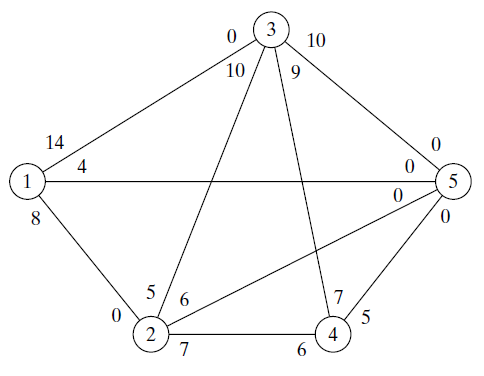



*   Para empezar realizamos el grafo, primero debemos de poner las librerias que se usaran en este caso son



In [162]:
import networkx as nx
import matplotlib.pyplot as plt



*   Creamos un grafo vacío, es decir, sin nodos ni aristas.



In [163]:
G = nx.Graph()

*   Agregamos los nodos de la red y sus atributos en este caso con el color     deseado con el formato :(node, node_attribute_dict)


In [164]:
G.add_nodes_from([
    (1, {"color": "red"}),
    (2, {"color": "red"}),
    (3, {"color": "red"}),
    (4, {"color": "red"}),
    (5, {"color": "red"}),

])


*   G también puede crecer añadiéndole aristas, se puede añadir un borde  con add_edge() o una lista de bordes con add_edges_from(). Con sus respectivos atributos: su color y su valor que en este caso se utiliza el comando "weight" de Networkx que significa peso o valor asociado a una arista (la línea que conecta dos nodos).

In [165]:
#Agregue/modifique atributos de borde usando add_edge(), add_edges_from(), su valor y su color,
G.add_edges_from([(1, 2, {"color": "green", "weight1": 8, "weight2": 0}),
                  (1,3, {"color": "green","weight1": 14, "weight2": 0}),
                  (1,5, {"color": "green","weight1": 4,"weight2": 0}),
                  (2,3, {"color": "red","weight1": 5, "weight2": 10}),
                  (2,4, {"color": "red","weight1":7, "weight2": 6}),
                  (2,5, {"color":"red","weight1": 6, "weight2": 0}),
                  (3,4, {"color": "red","weight1": 9, "weight2": 7}),
                  (3,5, {"color": "red","weight1": 10, "weight2": 0}),
                  ])

*   Obtenemos el color que tiene asignado cada nodo del grafo y lo guardamos en una lista para después poder usarlos al dibujar el grafo

In [166]:
node_colors = [
    G.nodes[n]["color"]
    for n in G.nodes()
]



*   Obtenemos el color de cada arista de igual manera para después poder usarlos al dibujar el grafo

In [167]:
edge_colors = [
    G[u][v]["color"]
    for u, v in G.edges()
]


*   Definimos la la posición de cada nodo con el formato : pos = {número_del_nodo: (posición_x, posición_y)}








In [168]:
pos = {
    1: (-4, 0),
    2: (1, 1),
    3: (1, -1),
    4: (12, 0),
    5: (18, 0)
}

* Definimos las características para dibujar el grafo.

In [169]:
options = {
    "font_size": 36,
    "node_size": 3000,
    "edgecolors": "black",
    "linewidths": 5,
    "width": 5,
}

*   Dibujamos el grafo, utilizando ***nx.draw()*** que es un comando de la biblioteca NetworkX que dibuja el grafo G y coloca cada nodo en la posición indicada en pos

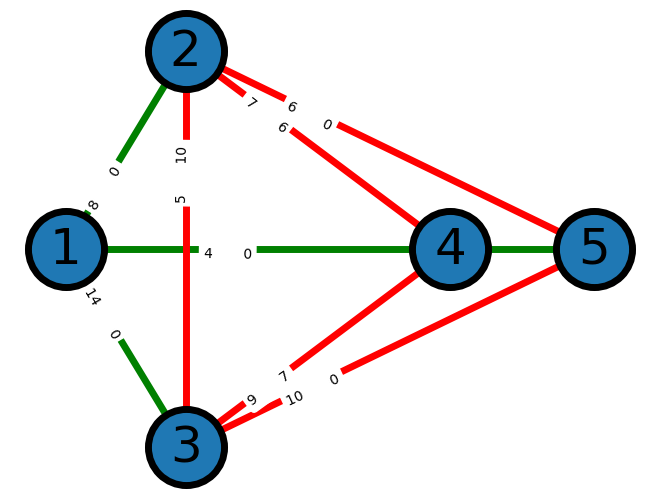

In [170]:
# Dibujamos el grafo.
nx.draw(
    G,
    pos,
    with_labels=True,
    edge_color=edge_colors,
    **options
)


# Obtenemos los valores
edge_labels = {
    (u, v): f"{data['weight1']}       {data['weight2']}"
    for u, v, data in G.edges(data=True)
    if "weight1" in data and "weight2" in data
}

# Mostramos los valores
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    label_pos=0.3,
    connectionstyle='arc3,rad=0.02',
)

# Mostramos el grafo.
plt.show()




*   Ahora resolvemos el ejemplo, con el Flujo Máximo
    
*   En este caso, vamos a ponerlo como red dirigida para resolverlo con el   
formato G.add_edge(u, v, capacity=c)




In [171]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

G.add_nodes_from([
    (1, {"color": "red"}),
    (2, {"color": "red"}),
    (3, {"color": "red"}),
    (4, {"color": "red"}),
    (5, {"color": "red"}),

])

#aqui lo cambiaremos ya que arriba solo era de dibujar, en este caso vamos a realizarlo con dirgida

G.add_edges_from([(1, 2, {"color": "green", "capacity": 8 }),
                  (2, 1, {"color": "green", "capacity": 0 }),
                  (1, 3, {"color": "green", "capacity": 14 }),
                  (3, 1, {"color": "green", "capacity": 0 }),
                  (4, 5, {"color": "green", "capacity": 5 }),
                  (5, 4, {"color": "green", "capacity": 0 }),
                  (1, 5, {"color": "green", "capacity": 4 }),
                  (5, 1, {"color": "green", "capacity": 0 }),
                  (2, 3, {"color": "green", "capacity": 5 }),
                  (3, 2, {"color": "green", "capacity": 10}),
                  (2, 5, {"color": "green", "capacity": 6}),
                  (5, 2, {"color": "green", "capacity": 0 }),
                  (2, 4, {"color": "green", "capacity": 7 }),
                  (4, 2, {"color": "green", "capacity": 6 }),
                  (3, 4, {"color": "green", "capacity": 9 }),
                  (4, 3, {"color": "green", "capacity": 7 }),
                  (3, 5, {"color": "green", "capacity": 10 }),
                  (5, 3, {"color": "green", "capacity": 0 })
                  ])


*   Obtenemos el color que tiene asignado cada nodo del grafo y lo guardamos en una lista para después poder usarlos al dibujar el grafo

In [172]:
node_colors = [
    G.nodes[n]["color"]
    for n in G.nodes()
]

*   Obtenemos el color de cada arista de igual manera para después poder usarlos al dibujar el grafo

In [173]:
edge_colors = [
    G[u][v]["color"]
    for u, v in G.edges()
]

*   Definimos la la posición de cada nodo con el formato : pos = {número_del_nodo: (posición_x, posición_y)}


In [174]:
pos = {
    1: (-4, 0),
    2: (1, -1),
    3: (3, 1),
    4: (12, -1),
    5: (18, 0)
}


* Definimos las características para dibujar el grafo.

In [175]:
options = {
    "font_size": 36,
    "node_size": 3000,
    "edgecolors": "black",
    "linewidths": 5,
    "width": 5,
}

*   Dibujamos el grafo, utilizando ***nx.draw()*** que es un comando de la biblioteca NetworkX que dibuja el grafo G y coloca cada nodo en la posición indicada en pos

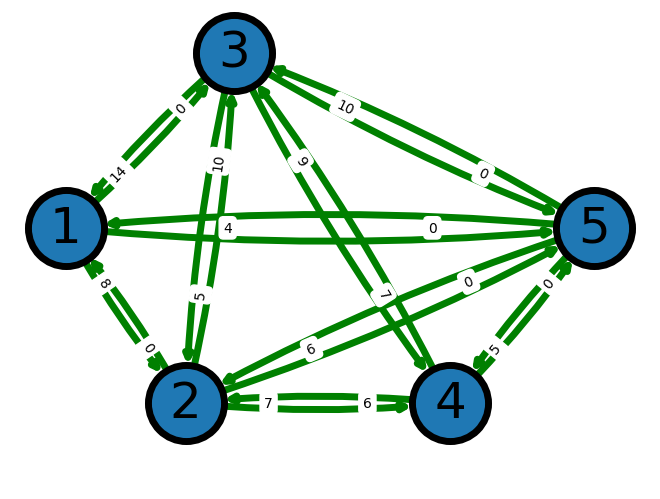

In [176]:
nx.draw(
    G,
    pos,
    with_labels=True,
    edge_color=edge_colors,
    connectionstyle="arc3,rad=0.05",
    **options
)


# Obtenemos las capacidades
edge_labels = nx.get_edge_attributes(G, "capacity")

# Mostramos las capacidades
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    label_pos=0.3
)

plt.show()




*   Calculamos el Flujo Maximo en este caso usaremos el comando ***nx.maximum_flow()*** es una función de NetworkX que calcula el flujo máximo de una red, ***flow_value*** guarda el valor total del flujo máximo y ***flow_dict*** guarda cuánto flujo pasa por cada arco.


In [177]:
flow_value, flow_dict = nx.maximum_flow(G, 1, 5)

print("Flujo máximo:", flow_value)

print("\nFlujo por cada arco:")

for u in flow_dict:
    for v in flow_dict[u]:
        if flow_dict[u][v] > 0:
            print(f"{u} -> {v}: {flow_dict[u][v]}")

Flujo máximo: 25

Flujo por cada arco:
1 -> 2: 7
1 -> 3: 14
1 -> 5: 4
2 -> 3: 2
2 -> 5: 6
3 -> 4: 6
3 -> 5: 10
4 -> 5: 5
4 -> 2: 1




*   Ahora bien dibujamos el grafo con los elementos anteriores.



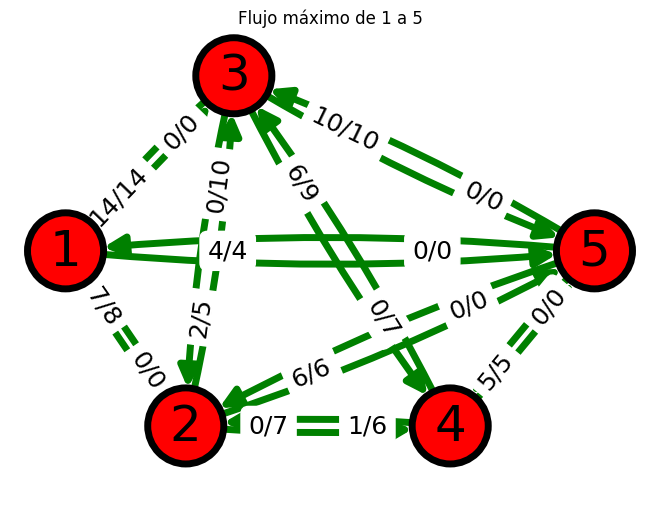

In [178]:
flow_labels = {}

for u, v in G.edges():
    flujo = flow_dict[u][v]
    capacidad = G[u][v]["capacity"]

    flow_labels[(u, v)] = f"{flujo}/{capacidad}" #aqui creamos las etiquetas de flujo/capacidad


#plt.figure(figsize=(18, 8)) #esto lo usamos para el tamaño del dibujo

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color=edge_colors,
    connectionstyle="arc3,rad=0.05",
    arrows=True,
    arrowsize=30,
    **options
)

# Mostramos flujo/capacidad en cada arco
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=flow_labels,
    label_pos=0.3,
    font_size=18
)

plt.title("Flujo máximo de 1 a 5")

plt.show()



Por lo tanto, obtenemos la solución del flujo máximo de la red.


---



#<font color="pink"> ***Referencias Bibliograficas***


*  Nos basamos en el documental:
https://networkx.org/documentation/latest/reference/classes/index.html

*  Taha, H. A. (2004). Investigación de operaciones (7.ª ed.). Pearson Educación de México. ISBN 970-26-0498-2.

*  Hillier, F. S., & Lieberman, G. J. (2010). Introducción a la investigación de operaciones (9.ª ed.). McGraw-Hill.